In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.data import DataLoader
from monai import transforms

# Importar tus clases unificadas
from src.get_data import UnifiedDataset
from src.custom_transforms import (
    ImputeMissingChannelsd,
    RandModalityDropoutd,
    ConvertToMultiChannelPipeline1d,
    ConvertToMultiChannelPipeline2d
)

Inicializando dataset de prueba para P1...
[TRAIN] Cargados 30 casos de UPenn-GBM (Pipeline 1)
[TRAIN] Cargados 273 casos de MU-Glioma Post (Pipeline 1)

¡Éxito! Paciente 'UPENN-GBM-00036' encontrado en el índice [0].
Cargando ground truth desde: ./Dataset/Dataset_30_6/train/labels/UPENN-GBM-00036_11_automated_approx_segm.nii.gz

Forma del tensor de imagen final: torch.Size([11, 160, 192, 160])
Forma del tensor de etiqueta final: torch.Size([2, 160, 192, 160])


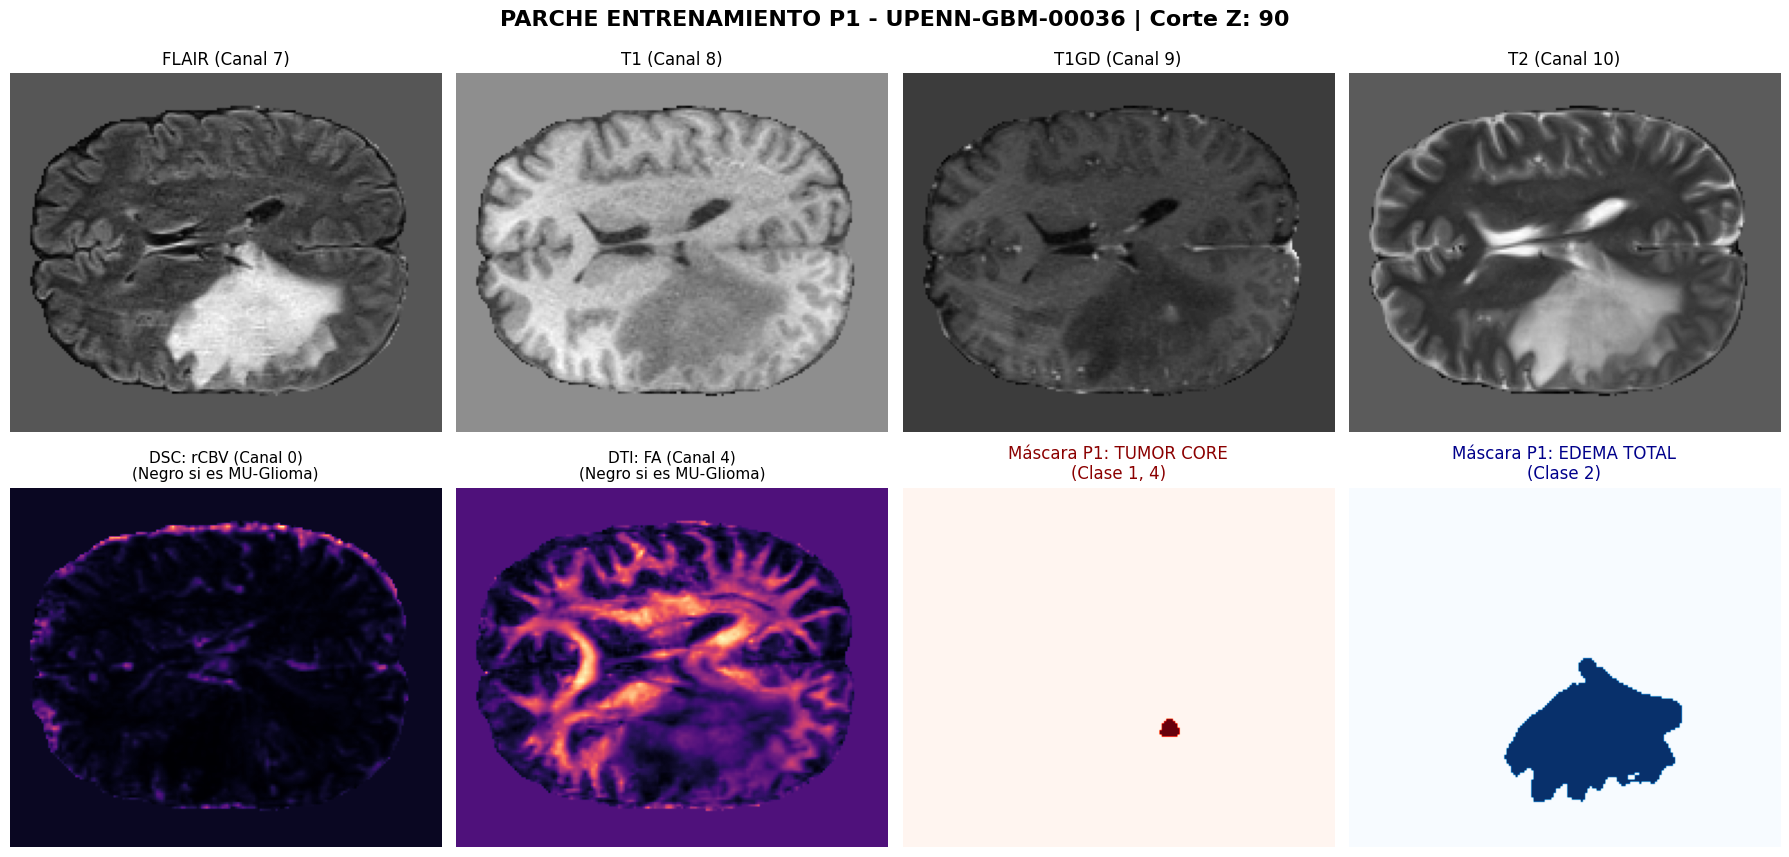

In [28]:

# 1. Definir Rutas (Ajusta estas a tus directorios reales del P1)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 1  # Pipeline 1 (Tumor Core vs Edema Total)

# Definir el paciente exacto que queremos buscar
# ID_BUSCADO = "PatientID_0005"  
ID_BUSCADO = "UPENN-GBM-00036" 

# 2. Definir las transformaciones de PRUEBA DE ENTRENAMIENTO
roi = (128, 128, 64)
test_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # Unificación de Canales a 11
    ImputeMissingChannelsd(keys=["image"]),
    
    # Dropout (0.0 para ver los datos reales en la gráfica sin apagarlos)
    RandModalityDropoutd(keys=["image"], prob=0.5),
    
    # Formateo de Etiquetas PARA PIPELINE 1 (Tumor Core y Edema Total)
    ConvertToMultiChannelPipeline1d(keys=["label"]),
    
    # Recorte inteligente con garantía matemática (Paso previo necesario)
    transforms.CropForegroundd(
        keys=["image", "label"], 
        source_key="image",
        margin=5,
        k_divisible=32,
        allow_smaller=False
    ),
    
    # Muestreo Balanceado: Extrae el parche real de 128x128x64 que verá la red
    transforms.RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 64),
        pos=1,          
        neg=1,          
        num_samples=1,  
        image_key="image",
        image_threshold=0,
    )
])

val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # 1. Unificación de canales (sin dropout para evaluar todo el potencial)
    ImputeMissingChannelsd(keys=["image"]),
    ConvertToMultiChannelPipeline1d(keys=["label"]),
    
    # 2. Recorte inteligente: Quita el aire negro, garantiza divisibilidad
    transforms.CropForegroundd(
        keys=["image", "label"], 
        source_key="image",
        margin=5,
        k_divisible=32,
        allow_smaller=False
    ),
    
    # (NOTA: No incluimos recortes aleatorios aquí para que sliding_window_inference 
    # evalúe el volumen completo del cerebro)
        
    # 3. Normalización final
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

myset=val_transform
# 3. Instanciar el Dataset Unificado
print("Inicializando dataset de prueba para P1...")
test_set = UnifiedDataset(
    upenn_dir=UPENN_DIR, 
    muglioma_dir=MUGLIOMA_DIR, 
    section="train", 
    pipeline=PIPELINE,
    transform=myset
)

# 4. Buscar el índice del paciente deseado
indice_encontrado = None
ruta_encontrada = ""

for i, data_dict in enumerate(test_set.data):
    if ID_BUSCADO in data_dict["label"]:
        indice_encontrado = i
        ruta_encontrada = data_dict["label"]
        break

# 5. Visualización del Parche Resultante
if indice_encontrado is not None:
    print(f"\n¡Éxito! Paciente '{ID_BUSCADO}' encontrado en el índice [{indice_encontrado}].")
    print(f"Cargando ground truth desde: {ruta_encontrada}")
    
    # EXTRAER EL CASO: [0] porque RandCrop devuelve una lista de diccionarios
    if myset == val_transform:
        caso_especifico = test_set[indice_encontrado]#[0]
    else:
        caso_especifico = test_set[indice_encontrado][0]

    imagen = caso_especifico["image"]   # Shape: [11, 128, 128, 64]
    etiqueta = caso_especifico["label"] # Shape: [2, 128, 128, 64]
    
    print(f"\nForma del tensor de imagen final: {imagen.shape}")
    print(f"Forma del tensor de etiqueta final: {etiqueta.shape}")
    
    # El corte central del parche ahora siempre será 32 (la mitad de 64)
    if myset == val_transform:
        corte_z = 90 #imagen.shape[-1] // 2
    else:
        corte_z = 32 #imagen.shape[-1] // 2

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f'PARCHE ENTRENAMIENTO P1 - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16, fontweight='bold')

    # Fila 1: Modalidades Estructurales (Índices 7 al 10)
    nombres_estructurales = ['FLAIR (Canal 7)', 'T1 (Canal 8)', 'T1GD (Canal 9)', 'T2 (Canal 10)']
    for i, ax in enumerate(axes[0]):
        canal_idx = i + 7
        ax.imshow(imagen[canal_idx, :, :, corte_z].numpy(), cmap="gray")
        ax.set_title(nombres_estructurales[i], fontsize=12)
        ax.axis("off")

    # Fila 2: Control de Imputación y Máscaras Pipeline 1
    axes[1, 0].imshow(imagen[0, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 0].set_title('DSC: rCBV (Canal 0)\n(Negro si es MU-Glioma)', fontsize=11)
    axes[1, 0].axis("off")

    axes[1, 1].imshow(imagen[4, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 1].set_title('DTI: FA (Canal 4)\n(Negro si es MU-Glioma)', fontsize=11)
    axes[1, 1].axis("off")

    # Máscaras del PIPELINE 1 (Aquí cambia el significado de los colores)
    axes[1, 2].imshow(etiqueta[0, :, :, corte_z].numpy(), cmap="Reds")
    axes[1, 2].set_title('Máscara P1: TUMOR CORE\n(Clase 1, 4)', fontsize=12, color='darkred')
    axes[1, 2].axis("off")

    axes[1, 3].imshow(etiqueta[1, :, :, corte_z].numpy(), cmap="Blues")
    axes[1, 3].set_title('Máscara P1: EDEMA TOTAL\n(Clase 2)', fontsize=12, color='darkblue')
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()

else:
    print(f"\n❌ Error: El paciente '{ID_BUSCADO}' no se encuentra en el dataset cargado.")

Inicializando dataset de prueba...
[TRAIN] Cargados 30 casos de UPenn-GBM (Pipeline 2)
[TRAIN] Cargados 190 casos de MU-Glioma Post (Pipeline 2)

¡Éxito! Paciente 'UPENN-GBM-00036' encontrado en el índice [0].
Cargando ground truth desde: ./Dataset/Dataset_30_6/train/labels/UPENN-GBM-00036_11_tumorMask2_approx_segm.nii.gz

Forma del tensor de imagen final: torch.Size([11, 160, 192, 160])
Forma del tensor de etiqueta final: torch.Size([2, 160, 192, 160])


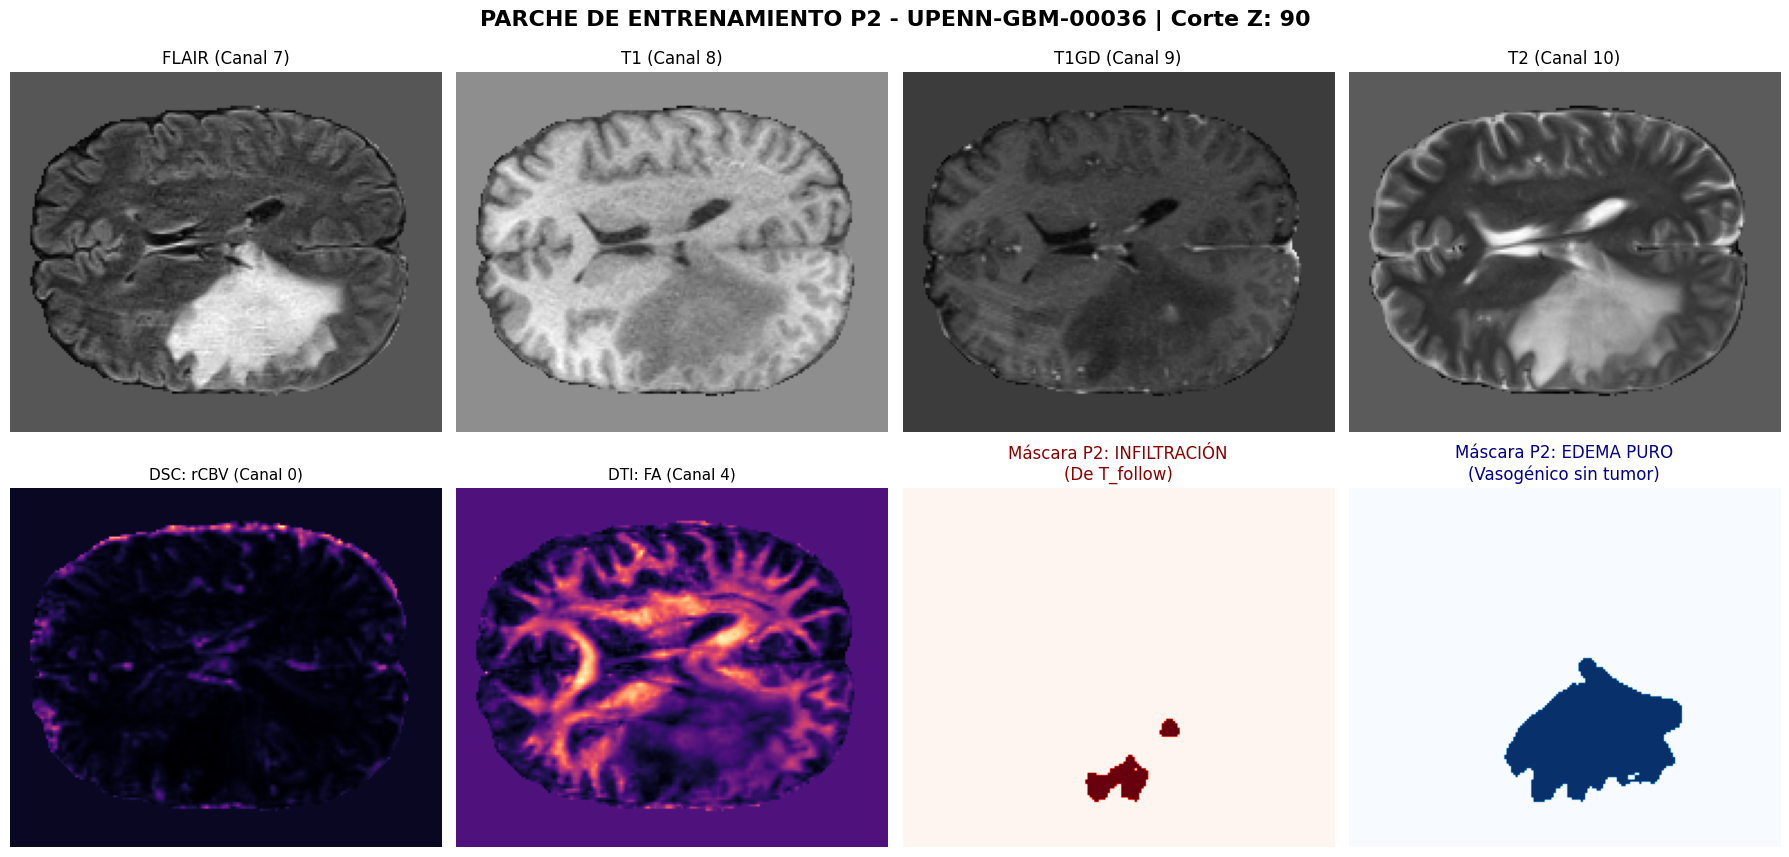

In [27]:
# 1. Definir Rutas (Ajusta estas a tus directorios reales)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 2  # Pipeline 2 (Infiltración vs Edema Puro)

# Definir el paciente exacto que queremos buscar
ID_BUSCADO = "UPENN-GBM-00036" 
# ID_BUSCADO = "PatientID_0060" 

# 2. Definir las transformaciones de PRUEBA DE ENTRENAMIENTO
# (Simulamos exactamente lo que verá la red en el paso forward)
test_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # Unificación de Canales a 11
    ImputeMissingChannelsd(keys=["image"]),
    
    # Dropout (0.0 para ver los datos reales en la gráfica)
    RandModalityDropoutd(keys=["image"], prob=0.5),
    
    # Formateo de Etiquetas PARA PIPELINE 2
    ConvertToMultiChannelPipeline2d(keys=["label"]),
    
    # Recorte inteligente con garantía de divisibilidad (Paso previo necesario)
    transforms.CropForegroundd(
        keys=["image", "label"], 
        source_key="image",
        margin=5,
        k_divisible=32,
        allow_smaller=False
    ),
    
    # Muestreo Balanceado: Extrae el parche real de 128x128x64 que verá la red
    transforms.RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 64),
        pos=1,          
        neg=1,          
        num_samples=1,  
        image_key="image",
        image_threshold=0,
    )
])

val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # 1. Unificación de canales (sin dropout para evaluar todo el potencial)
    ImputeMissingChannelsd(keys=["image"]),
    ConvertToMultiChannelPipeline2d(keys=["label"]),
    
    # 2. Recorte inteligente: Quita el aire negro, garantiza divisibilidad
    transforms.CropForegroundd(
        keys=["image", "label"], 
        source_key="image",
        margin=5,
        k_divisible=32,
        allow_smaller=False
    ),
    
    # (NOTA: No incluimos recortes aleatorios aquí para que sliding_window_inference 
    # evalúe el volumen completo del cerebro)
        
    # 3. Normalización final
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

myset = val_transform
# 3. Instanciar el Dataset Unificado
print("Inicializando dataset de prueba...")
test_set = UnifiedDataset(
    upenn_dir=UPENN_DIR, 
    muglioma_dir=MUGLIOMA_DIR, 
    section="train", 
    pipeline=PIPELINE,
    transform=myset
)

# 4. Buscar el índice del paciente deseado
indice_encontrado = None
ruta_encontrada = ""

for i, data_dict in enumerate(test_set.data):
    if ID_BUSCADO in data_dict["label"]:
        indice_encontrado = i
        ruta_encontrada = data_dict["label"]
        break

# 5. Visualización del Parche Resultante
if indice_encontrado is not None:
    print(f"\n¡Éxito! Paciente '{ID_BUSCADO}' encontrado en el índice [{indice_encontrado}].")
    print(f"Cargando ground truth desde: {ruta_encontrada}")
    
    # EXTRAER EL CASO: Notar el [0] al final porque RandCrop devuelve una lista
    if myset == val_transform:
        caso_especifico = test_set[indice_encontrado]#[0]
    else:   
        caso_especifico = test_set[indice_encontrado][0]
    
    imagen = caso_especifico["image"]   # Shape esperado: [11, 128, 128, 64]
    etiqueta = caso_especifico["label"] # Shape esperado: [2, 128, 128, 64]
    
    print(f"\nForma del tensor de imagen final: {imagen.shape}")
    print(f"Forma del tensor de etiqueta final: {etiqueta.shape}")
    
    # El corte central del parche ahora será 32 (la mitad de 64)
    if myset == val_transform:
        corte_z = 90 #imagen.shape[-1] // 2
    else:
        corte_z = 32 #imagen.shape[-1] // 2

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f'PARCHE DE ENTRENAMIENTO P2 - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16, fontweight='bold')

    # Fila 1: Modalidades Estructurales (Índices 7 al 10)
    nombres_estructurales = ['FLAIR (Canal 7)', 'T1 (Canal 8)', 'T1GD (Canal 9)', 'T2 (Canal 10)']
    for i, ax in enumerate(axes[0]):
        canal_idx = i + 7
        ax.imshow(imagen[canal_idx, :, :, corte_z].numpy(), cmap="gray")
        ax.set_title(nombres_estructurales[i], fontsize=12)
        ax.axis("off")

    # Fila 2: Control de Imputación y Máscaras Pipeline 2
    axes[1, 0].imshow(imagen[0, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 0].set_title('DSC: rCBV (Canal 0)', fontsize=11)
    axes[1, 0].axis("off")

    axes[1, 1].imshow(imagen[4, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 1].set_title('DTI: FA (Canal 4)', fontsize=11)
    axes[1, 1].axis("off")

    # Máscaras del PIPELINE 2
    axes[1, 2].imshow(etiqueta[0, :, :, corte_z].numpy(), cmap="Reds")
    axes[1, 2].set_title('Máscara P2: INFILTRACIÓN\n(De T_follow)', fontsize=12, color='darkred')
    axes[1, 2].axis("off")

    axes[1, 3].imshow(etiqueta[1, :, :, corte_z].numpy(), cmap="Blues")
    axes[1, 3].set_title('Máscara P2: EDEMA PURO\n(Vasogénico sin tumor)', fontsize=12, color='darkblue')
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()

else:
    print(f"\n❌ Error: El paciente '{ID_BUSCADO}' no se encuentra en el dataset cargado.")

## Pruebas de inferencia pipeline1

In [1]:
import os
import torch
from monai import transforms
from monai.networks.nets import SwinUNETR

# Importar tus clases unificadas
from src.get_data import UnifiedDataset
from src.custom_transforms import (
    ImputeMissingChannelsd,
    ConvertToMultiChannelPipeline2d, ConvertToMultiChannelPipeline1d
)

# 1. Definir Rutas (Ajustadas al Pipeline 2)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 1

# Ruta a tus mejores pesos de la Fase 1
MODEL_WEIGHTS_PATH = "./Dataset_Output/pipe1/expert-durian-7/model_best.pt"
roi = (128, 128, 64)

# 2. Transformaciones de Validación (Cerebro Completo)
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # Unificación de los 11 canales
    ImputeMissingChannelsd(keys=["image"]),
    
    # Mapeo: Canal 0 -> Tumor Core | Canal 1 -> Edema Total
    ConvertToMultiChannelPipeline1d(keys=["label"]),
    
    # # Recorte del fondo garantizando divisibilidad por 32
    # transforms.CropForegroundd(
    #     keys=["image", "label"], 
    #     source_key="image",
    #     margin=5,
    #     k_divisible=32,
    #     allow_smaller=False
    # ),
        
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

# 3. Instanciar Dataset
print(f"Cargando Dataset para Pipeline {PIPELINE}...")
test_set = UnifiedDataset(
    upenn_dir=UPENN_DIR, 
    muglioma_dir=MUGLIOMA_DIR, 
    section="train", 
    pipeline=PIPELINE,
    transform=val_transform
)

# 4. Cargar Modelo SwinUNETR
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SwinUNETR(
    img_size=roi,
    in_channels=11,  
    out_channels=2,  # [Tumor Core, Edema Total]
    feature_size=48,
    use_checkpoint=True,
)

if os.path.exists(MODEL_WEIGHTS_PATH):
    checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    print(f"¡Pesos de Pipeline 1 cargados desde {MODEL_WEIGHTS_PATH}!")
else:
    print("⚠️ No se encontraron los pesos. Verificando ruta...")

model.to(device)
model.eval()
print("\nSetup listo para inferencia en Pipeline 1.")

Cargando Dataset para Pipeline 1...
[TRAIN] Cargados 30 casos de UPenn-GBM (Pipeline 1)
[TRAIN] Cargados 273 casos de MU-Glioma Post (Pipeline 1)


/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


¡Pesos de Pipeline 1 cargados desde ./Dataset_Output/pipe1/expert-durian-7/model_best.pt!

Setup listo para inferencia en Pipeline 1.


¡Evaluando paciente 'UPENN-GBM-00036'!
Realizando inferencia con sliding_window_inference...
Mostrando corte Z: 101 (Z-slice con mayor área tumoral)


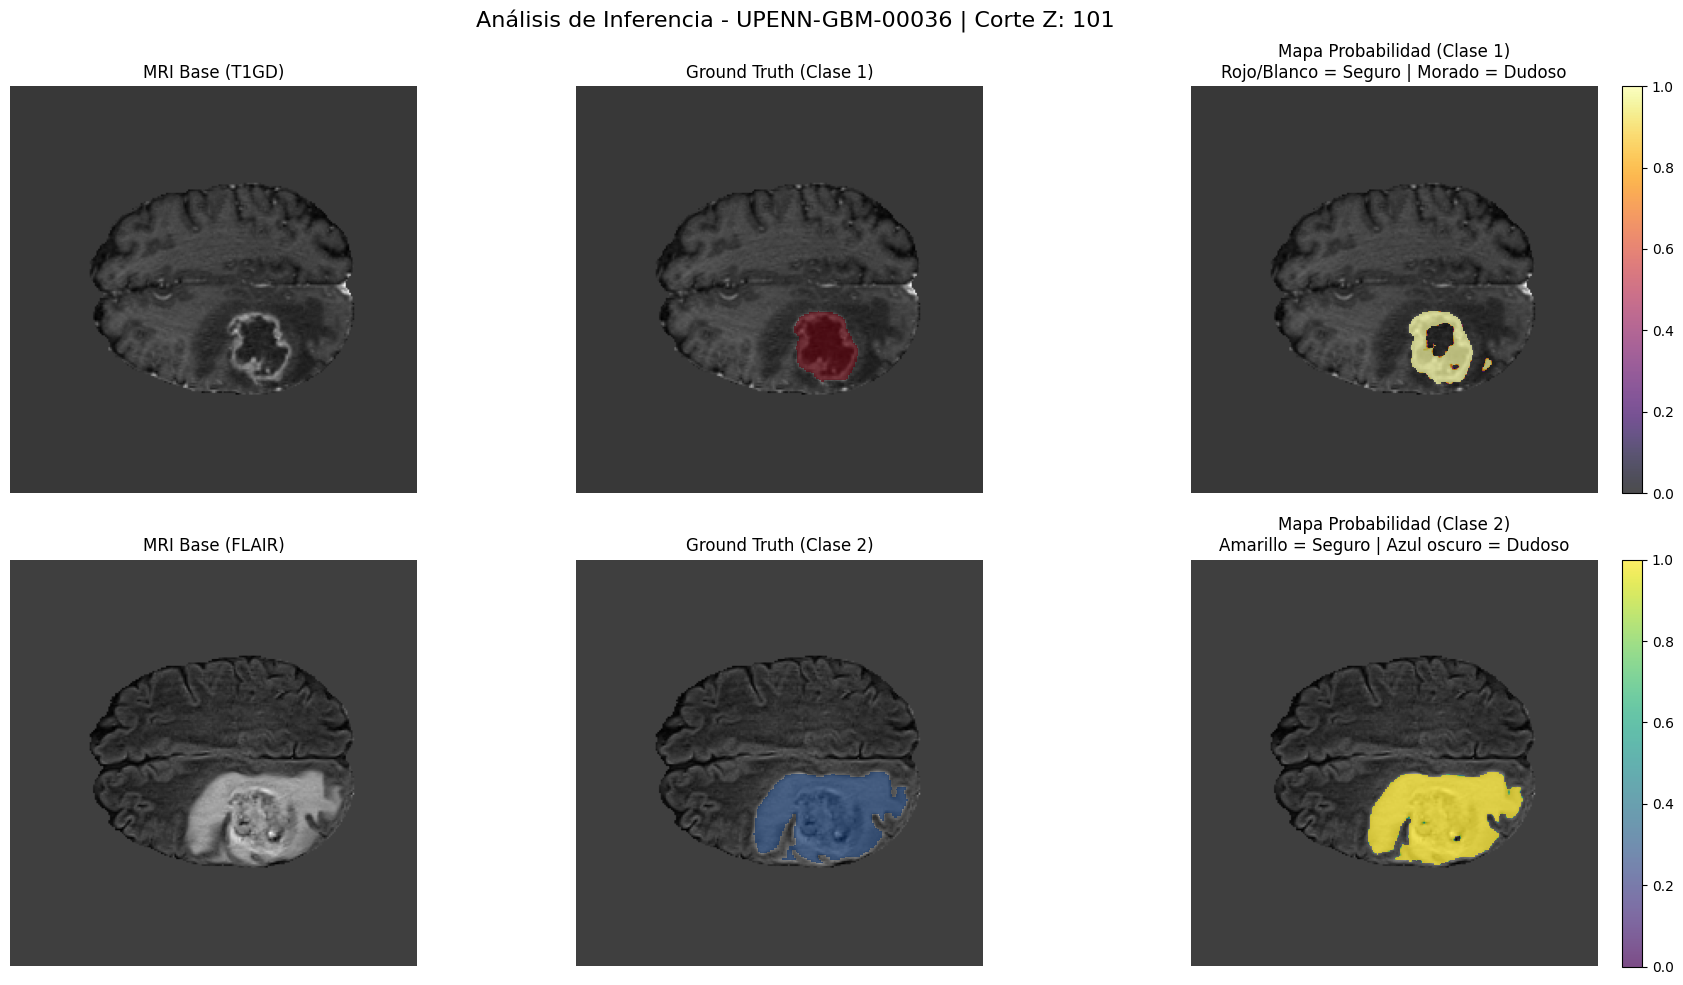

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference

# 1. Configuración de búsqueda e inferencia
ID_BUSCADO = "UPENN-GBM-00036"  # Cambia al ID que quieras evaluar
# ID_BUSCADO = "PatientID_0065" 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.eval()  # Asegurarnos que el modelo está en modo evaluación

# Buscar el índice
indice_encontrado = None
for i, data_dict in enumerate(test_set.data):
    if ID_BUSCADO in data_dict["label"]:
        indice_encontrado = i
        break

if indice_encontrado is not None:
    print(f"¡Evaluando paciente '{ID_BUSCADO}'!")
    
    # 2. Cargar datos y enviar a GPU
    # Recordar que si usamos RandCropByPosNegLabeld en train_transform, devuelve lista.
    # En val_transform (cerebro completo) no devuelve lista. 
    # Hacemos un manejo seguro para ambos casos:
    datos = test_set[indice_encontrado]
    if isinstance(datos, list):
        datos = datos[0]
        
    imagen = datos["image"].unsqueeze(0).to(device) # Añadir dimensión Batch -> [1, 11, H, W, D]
    etiqueta = datos["label"].unsqueeze(0).to(device) # -> [1, 2, H, W, D]
    
    # 3. Ejecutar Inferencia (Sliding Window)
    print("Realizando inferencia con sliding_window_inference...")
    with torch.no_grad():
        # Obtenemos los logits crudos (valores sin normalizar entre -inf y +inf)
        logits = sliding_window_inference(
            inputs=imagen,
            roi_size=(128, 128, 64),
            sw_batch_size=2,
            predictor=model,
            overlap=0.5
        )
        # Aplicar Sigmoide para obtener probabilidades reales entre 0.0 y 1.0
        probabilidades = torch.sigmoid(logits)

    # 4. Bajar a CPU y convertir a Numpy para Matplotlib
    img_np = imagen[0].cpu().numpy()
    gt_np = etiqueta[0].cpu().numpy()
    prob_np = probabilidades[0].cpu().numpy()
    
    # 5. Encontrar el corte Z con más tumor para que la visualización valga la pena
    suma_por_corte = np.sum(gt_np[0] + gt_np[1], axis=(0, 1))
    corte_z = np.argmax(suma_por_corte)
    if suma_por_corte[corte_z] == 0:
        corte_z = img_np.shape[-1] // 2 # Si no hay tumor, mostrar el centro
        
    print(f"Mostrando corte Z: {corte_z} (Z-slice con mayor área tumoral)")

    # 6. Visualización
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Análisis de Inferencia - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16)

    # --- FILA 1: CANAL 0 (Tumor Core o Infiltración) ---
    # Imagen Estructural de Fondo (T1GD suele ser el canal 9 en tu setup de 11 canales)
    t1gd_bg = img_np[9, :, :, corte_z]
    
    # 1.1 Resonancia Base
    axes[0, 0].imshow(t1gd_bg, cmap="gray")
    axes[0, 0].set_title('MRI Base (T1GD)')
    axes[0, 0].axis('off')

    # 1.2 Ground Truth
    axes[0, 1].imshow(t1gd_bg, cmap="gray")
    # Superponemos la máscara real con alpha (transparencia)
    gt_masked_0 = np.ma.masked_where(gt_np[0, :, :, corte_z] == 0, gt_np[0, :, :, corte_z])
    axes[0, 1].imshow(gt_masked_0, cmap="Reds", alpha=0.6, vmin=0, vmax=1)
    axes[0, 1].set_title('Ground Truth (Clase 1)')
    axes[0, 1].axis('off')

    # 1.3 Mapa de Probabilidad (Predicción de la Red)
    axes[0, 2].imshow(t1gd_bg, cmap="gray")
    prob_masked_0 = np.ma.masked_where(prob_np[0, :, :, corte_z] < 0.05, prob_np[0, :, :, corte_z]) # Ocultar ruido bajísimo
    im0 = axes[0, 2].imshow(prob_masked_0, cmap="inferno", alpha=0.7, vmin=0, vmax=1)
    axes[0, 2].set_title('Mapa Probabilidad (Clase 1)\nRojo/Blanco = Seguro | Morado = Dudoso')
    axes[0, 2].axis('off')
    fig.colorbar(im0, ax=axes[0, 2], fraction=0.046, pad=0.04)

    # --- FILA 2: CANAL 1 (Edema Total o Edema Vasogénico) ---
    # Imagen Estructural de Fondo (FLAIR suele ser el canal 7)
    flair_bg = img_np[7, :, :, corte_z]

    # 2.1 Resonancia Base
    axes[1, 0].imshow(flair_bg, cmap="gray")
    axes[1, 0].set_title('MRI Base (FLAIR)')
    axes[1, 0].axis('off')

    # 2.2 Ground Truth
    axes[1, 1].imshow(flair_bg, cmap="gray")
    gt_masked_1 = np.ma.masked_where(gt_np[1, :, :, corte_z] == 0, gt_np[1, :, :, corte_z])
    axes[1, 1].imshow(gt_masked_1, cmap="Blues", alpha=0.6, vmin=0, vmax=1)
    axes[1, 1].set_title('Ground Truth (Clase 2)')
    axes[1, 1].axis('off')

    # 2.3 Mapa de Probabilidad (Predicción de la Red)
    axes[1, 2].imshow(flair_bg, cmap="gray")
    prob_masked_1 = np.ma.masked_where(prob_np[1, :, :, corte_z] < 0.05, prob_np[1, :, :, corte_z])
    im1 = axes[1, 2].imshow(prob_masked_1, cmap="viridis", alpha=0.7, vmin=0, vmax=1)
    axes[1, 2].set_title('Mapa Probabilidad (Clase 2)\nAmarillo = Seguro | Azul oscuro = Dudoso')
    axes[1, 2].axis('off')
    fig.colorbar(im1, ax=axes[1, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    
else:
    print(f"Paciente {ID_BUSCADO} no encontrado.")

## Evaluacion pipeline2

[TRAIN] Cargados 30 casos de UPenn-GBM (Pipeline 2)
[TRAIN] Cargados 190 casos de MU-Glioma Post (Pipeline 2)
Pesos P2 cargados.


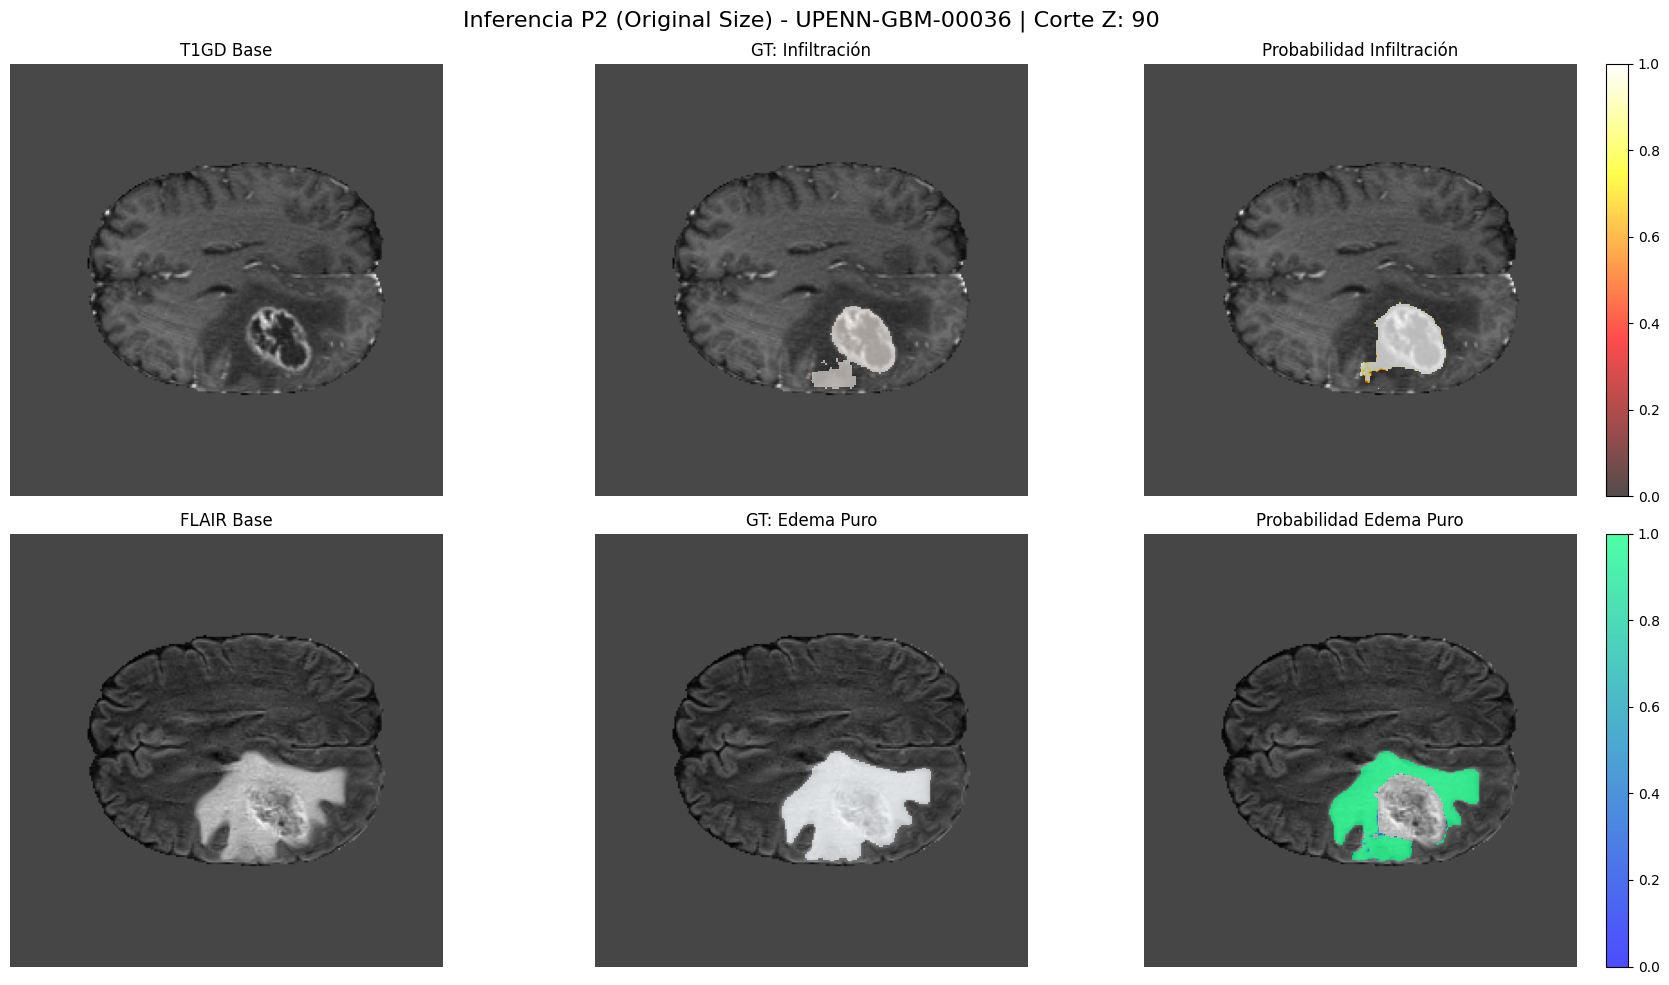

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.networks.nets import SwinUNETR

# Importar tus clases unificadas
from src.get_data import UnifiedDataset
from src.custom_transforms import (
    ImputeMissingChannelsd,
    ConvertToMultiChannelPipeline2d, ConvertToMultiChannelPipeline1d
)

# 1. SETUP DE DATOS Y MODELO (Ajustado a Pipeline 2)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 2
MODEL_WEIGHTS_PATH = "./Dataset_Output/pipe2/curious-frog-2/model_best.pt"
roi = (128, 128, 64)
ID_BUSCADO = "UPENN-GBM-00036" 
# ID_BUSCADO = "PatientID_0060" 

# Transformación de Validación SIN RECORTE
val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    ImputeMissingChannelsd(keys=["image"]),
    ConvertToMultiChannelPipeline2d(keys=["label"]),
    # Se eliminó CropForegroundd para mantener dimensiones originales 240x240x155
    transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

# Instanciar Dataset y cargar Modelo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_set = UnifiedDataset(upenn_dir=UPENN_DIR, muglioma_dir=MUGLIOMA_DIR, section="train", pipeline=PIPELINE, transform=val_transform)

model = SwinUNETR(img_size=roi, in_channels=11, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
if os.path.exists(MODEL_WEIGHTS_PATH):
    checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    print("Pesos P2 cargados.")
model.eval()

# 2. BÚSQUEDA E INFERENCIA
indice_encontrado = next((i for i, d in enumerate(test_set.data) if ID_BUSCADO in d["label"]), None)

if indice_encontrado is not None:
    # Cargar caso completo (al no haber recorte, el tensor será de tamaño original)
    datos = test_set[indice_encontrado]
    imagen = datos["image"].unsqueeze(0).to(device) # [1, 11, H, W, D]
    etiqueta = datos["label"].unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = sliding_window_inference(imagen, roi, sw_batch_size=2, predictor=model, overlap=0.5)
        probabilidades = torch.sigmoid(logits)

    img_np = imagen[0].cpu().numpy()
    gt_np = etiqueta[0].cpu().numpy()
    prob_np = probabilidades[0].cpu().numpy()
    
    # Corte Z óptimo (donde hay más infiltración)
    corte_z = np.argmax(np.sum(gt_np[0], axis=(0, 1)))
    corte_z=90
    
    # 3. VISUALIZACIÓN
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Inferencia P2 (Original Size) - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16)

    # Canal 0: Infiltración (Fondo T1GD)
    bg0 = img_np[9, :, :, corte_z]
    axes[0, 0].imshow(bg0, cmap="gray"); axes[0, 0].set_title('T1GD Base'); axes[0, 0].axis('off')
    
    axes[0, 1].imshow(bg0, cmap="gray")
    gt0 = np.ma.masked_where(gt_np[0, :, :, corte_z] == 0, gt_np[0, :, :, corte_z])
    axes[0, 1].imshow(gt0, cmap="Reds", alpha=0.6); axes[0, 1].set_title('GT: Infiltración'); axes[0, 1].axis('off')

    axes[0, 2].imshow(bg0, cmap="gray")
    p0 = np.ma.masked_where(prob_np[0, :, :, corte_z] < 0.1, prob_np[0, :, :, corte_z])
    im0 = axes[0, 2].imshow(p0, cmap="hot", alpha=0.7, vmin=0, vmax=1)
    axes[0, 2].set_title('Probabilidad Infiltración'); axes[0, 2].axis('off')
    fig.colorbar(im0, ax=axes[0, 2])

    # Canal 1: Edema Puro (Fondo FLAIR)
    bg1 = img_np[7, :, :, corte_z]
    axes[1, 0].imshow(bg1, cmap="gray"); axes[1, 0].set_title('FLAIR Base'); axes[1, 0].axis('off')

    axes[1, 1].imshow(bg1, cmap="gray")
    gt1 = np.ma.masked_where(gt_np[1, :, :, corte_z] == 0, gt_np[1, :, :, corte_z])
    axes[1, 1].imshow(gt1, cmap="Blues", alpha=0.6); axes[1, 1].set_title('GT: Edema Puro'); axes[1, 1].axis('off')

    axes[1, 2].imshow(bg1, cmap="gray")
    p1 = np.ma.masked_where(prob_np[1, :, :, corte_z] < 0.1, prob_np[1, :, :, corte_z])
    im1 = axes[1, 2].imshow(p1, cmap="winter", alpha=0.7, vmin=0, vmax=1)
    axes[1, 2].set_title('Probabilidad Edema Puro'); axes[1, 2].axis('off')
    fig.colorbar(im1, ax=axes[1, 2])

    plt.tight_layout(); plt.show()

